# EDA de PM2.5 en Santa Anita

**Primera entrega — enero de 2022 a abril de 2024**

Buscamos predecir la concentración de PM2.5 exactamente una hora después usando su historial reciente, y estudiar el aporte de la hora del día y del día de la semana. Esta notebook desarrolla el análisis exploratorio, sin entrenar modelos.

## Preguntas de investigación

1. ¿Cuánto mejora un modelo de aprendizaje automático sobre la persistencia —usar la medición actual como pronóstico de la siguiente hora— en un horizonte de una hora?
2. ¿Aportan las variables de calendario (hora del día y día de la semana) por encima de lo que ya contiene el historial reciente de la propia serie?
3. ¿Se degrada el desempeño en el régimen de concentraciones altas, que es el de mayor relevancia sanitaria?

Esta entrega no responde ninguna de las tres: reúne la evidencia descriptiva necesaria para plantearlas y para diseñar el experimento que las responderá en la segunda etapa.

## Datos

Fuente: [SENAMHI — Plataforma Nacional de Datos Abiertos](https://www.datosabiertos.gob.pe/dataset/monitoreo-de-los-contaminantes-del-aire-en-lima-metropolitana-servicio-nacional-de). Licencia indicada: Open Data Commons Attribution License. El CSV fue filtrado por el equipo para conservar Santa Anita. Se mantiene intacto en `data/raw/`.

Se sigue la secuencia de la notebook del curso `session-01c-eda-and-cleaning.ipynb`: estructura, calidad, resúmenes y decisiones de preparación. Los gráficos se guardan en PNG (300 dpi) y PDF vectorial en `figures/`; las tablas, en `data/processed/`.

**Unidad:** las concentraciones están expresadas en **µg/m³**. El diccionario del portal no lo declara, pero el informe de vigilancia de la calidad del aire de SENAMHI para el Área Metropolitana de Lima y Callao (2021) reporta PM10, PM2.5 y NO2 en esa unidad para esta misma red de estaciones. El mismo informe confirma que Santa Anita forma parte de la zona este de la red, junto con San Juan de Lurigancho, Ate y Ceres.

**Umbrales de referencia.** El Estándar de Calidad Ambiental del Perú (D.S. 003-2017-MINAM) fija 50 µg/m³ como promedio de 24 horas para PM2.5; la guía de la Organización Mundial de la Salud (2021) recomienda 15 µg/m³ para el mismo promedio. Ambos son diarios, de modo que solo se comparan contra medias diarias, nunca contra mediciones horarias.

## 1. Carga de datos
Ejecutar las celdas en orden desde la raíz del repositorio o desde `notebooks/`. No se necesitan rutas personales.

In [1]:
from pathlib import Path
import hashlib
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown

SEMILLA = 42
np.random.seed(SEMILLA)

ROOT = Path.cwd().resolve()
if not (ROOT / 'data/raw/santa_anita_2015_2024.csv').exists():
    ROOT = ROOT.parent
CSV = ROOT / 'data/raw/santa_anita_2015_2024.csv'
assert CSV.exists(), 'Abrir la notebook desde la raíz del repositorio o notebooks/.'
FIG = ROOT / 'figures'
OUT = ROOT / 'data/processed'
FIG.mkdir(exist_ok=True)
OUT.mkdir(exist_ok=True)
hash_original = hashlib.sha256(CSV.read_bytes()).hexdigest()
plt.rcParams.update({'figure.figsize': (8, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'savefig.facecolor': 'white'})
COLOR = '#176B87'
ACENTO = '#C55A11'
UNIDAD = 'PM2.5 (µg/m³)'
ECA_DIARIO = 50    # D.S. 003-2017-MINAM, promedio de 24 h
OMS_DIARIO = 15    # OMS 2021, promedio de 24 h

def guardar(fig, nombre):
    fig.tight_layout()
    fig.savefig(FIG / f'{nombre}.png', dpi=300, bbox_inches='tight')
    fig.savefig(FIG / f'{nombre}.pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)

def tabla(df, nombre):
    df.to_csv(OUT / f'{nombre}.csv', encoding='utf-8', index=True)
    vista = df.copy()
    numericas = vista.select_dtypes(include="number").columns
    vista[numericas] = vista[numericas].round(3)
    display(vista)

raw = pd.read_csv(CSV, dtype={'FECHA': 'string', 'HORA': 'string', 'UBIGEO': 'string'})
print(f'Archivo de Santa Anita: {raw.shape[0]:,} filas y {raw.shape[1]} columnas.')
display(raw.head())
raw.info()
print('Versiones:', platform.python_version(), 'pandas', pd.__version__,
      'numpy', np.__version__, 'matplotlib', matplotlib.__version__)
print('Semilla global:', SEMILLA)

Archivo de Santa Anita: 82,542 filas y 15 columnas.


,ID,ESTACION,FECHA,HORA,LONGITUD,LATITUD,ALTITUD,PM10,PM2_5,NO2,DEPARTAMENTO,PROVINCIA,DISTRITO,UBIGEO,FECHA_CORTE
0,165085,SANTA_ANITA,20150101,50000,-76.9714,-12.043,253,103.93,13.4,NaN,LIMA,LIMA,SANTA_ANITA,150137,20240531
1,165086,SANTA_ANITA,20150101,60000,-76.9714,-12.043,253,293.73,102.4,NaN,LIMA,LIMA,SANTA_ANITA,150137,20240531
2,165087,SANTA_ANITA,20150101,70000,-76.9714,-12.043,253,168.25,118.8,NaN,LIMA,LIMA,SANTA_ANITA,150137,20240531
3,165088,SANTA_ANITA,20150101,80000,-76.9714,-12.043,253,165.57,87.9,NaN,LIMA,LIMA,SANTA_ANITA,150137,20240531
4,165089,SANTA_ANITA,20150101,90000,-76.9714,-12.043,253,81.51,66.7,NaN,LIMA,LIMA,SANTA_ANITA,150137,20240531


<class 'pandas.DataFrame'>
RangeIndex: 82542 entries, 0 to 82541
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            82542 non-null  int64  
 1   ESTACION      82542 non-null  str    
 2   FECHA         82542 non-null  string 
 3   HORA          82542 non-null  string 
 4   LONGITUD      82542 non-null  float64
 5   LATITUD       82542 non-null  float64
 6   ALTITUD       82542 non-null  int64  
 7   PM10          68300 non-null  float64
 8   PM2_5         50613 non-null  float64
 9   NO2           44450 non-null  float64
 10  DEPARTAMENTO  82542 non-null  str    
 11  PROVINCIA     82542 non-null  str    
 12  DISTRITO      82542 non-null  str    
 13  UBIGEO        82542 non-null  string 
 14  FECHA_CORTE   82542 non-null  int64  
dtypes: float64(5), int64(3), str(4), string(3)
memory usage: 9.4 MB
Versiones: 3.12.3 pandas 3.0.1 numpy 2.5.3 matplotlib 3.11.2
Semilla global: 42


## 2. Selección del periodo de estudio
Primero comprobamos las fechas y la estación. El gráfico histórico cuenta horas con al menos una medición disponible; no promedia ni selecciona las concentraciones duplicadas. En 2015 se incluyen las cinco primeras horas del año en el denominador, aunque el archivo empieza a las 05:00. En 2024 solo se incluyen enero–mayo.

Periodo del archivo: 2015-01-01 05:00:00 a 2024-05-31 23:00:00
Registros adicionales con fecha/hora repetida: 12


,horas_esperadas,horas_con_PM25,cobertura_pct
2015,8760,8250,94.178
2016,8784,7434,84.631
2017,8760,8258,94.269
2018,8760,4397,50.194
2019,8760,1832,20.913
2020,8784,0,0.000
2021,8760,303,3.459
2022,8760,8236,94.018
2023,8760,8326,95.046
2024,3648,3565,97.725


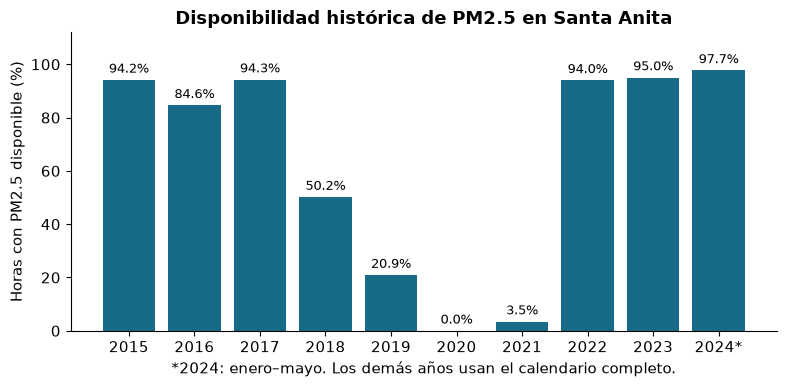

In [2]:
datos = raw.copy()
datos['fecha_hora'] = pd.to_datetime(
    datos['FECHA'] + datos['HORA'].str.zfill(6),
    format='%Y%m%d%H%M%S', errors='coerce')
assert datos['fecha_hora'].notna().all(), 'Revisar fechas que no pudieron interpretarse.'
assert set(datos['ESTACION'].unique()) == {'SANTA_ANITA'}
assert datos['fecha_hora'].eq(datos['fecha_hora'].dt.floor('h')).all()
print('Periodo del archivo:', datos['fecha_hora'].min(), 'a', datos['fecha_hora'].max())
print('Registros adicionales con fecha/hora repetida:', datos['fecha_hora'].duplicated().sum())
disponible = datos.assign(disponible=datos['PM2_5'].notna()).groupby('fecha_hora')['disponible'].any()
rejilla_hist = pd.date_range('2015-01-01', '2024-05-31 23:00', freq='h')
hist = disponible.reindex(rejilla_hist, fill_value=False)
cob_anual = hist.groupby(hist.index.year).agg(['size', 'sum'])
cob_anual.columns = ['horas_esperadas', 'horas_con_PM25']
cob_anual['cobertura_pct'] = 100 * cob_anual.horas_con_PM25 / cob_anual.horas_esperadas
tabla(cob_anual, 'cobertura_anual_historica')
fig, ax = plt.subplots(figsize=(8, 4))
etiquetas = [str(y) if y != 2024 else '2024*' for y in cob_anual.index]
barras = ax.bar(etiquetas, cob_anual.cobertura_pct, color=COLOR)
ax.bar_label(barras, labels=[f'{v:.1f}%' for v in cob_anual.cobertura_pct], fontsize=9, padding=3)
ax.set(ylabel='Horas con PM2.5 disponible (%)', ylim=(0, 112),
       title='Disponibilidad histórica de PM2.5 en Santa Anita')
ax.set_xlabel('*2024: enero–mayo. Los demás años usan el calendario completo.')
guardar(fig, '01_cobertura_anual')

In [3]:
INICIO = pd.Timestamp('2022-01-01 00:00')
FIN = pd.Timestamp('2024-04-30 23:00')
periodo = datos.loc[datos.fecha_hora.between(INICIO, FIN)].sort_values('fecha_hora').copy()
assert not periodo.fecha_hora.duplicated().any(), 'Resolver duplicados antes de continuar.'
rejilla = pd.date_range(INICIO, FIN, freq='h', name='fecha_hora')
horas_sin_fila = len(rejilla.difference(pd.DatetimeIndex(periodo.fecha_hora)))
df = periodo.set_index('fecha_hora').reindex(rejilla)
s = df['PM2_5']
resumen = pd.DataFrame({'valor': {
    'Horas esperadas': len(rejilla), 'Filas en el periodo': len(periodo),
    'Horas sin fila': horas_sin_fila, 'Mediciones PM2.5 disponibles': s.count(),
    'PM2.5 faltantes': s.isna().sum(), 'Cobertura (%)': 100*s.notna().mean(),
    'Duplicados fecha/hora': periodo.fecha_hora.duplicated().sum()}})
tabla(resumen, 'resumen_periodo')
display(Markdown(f'El periodo contiene **{len(df):,} horas**, con **{s.count():,} mediciones** '
                 f'y **{s.isna().sum():,} faltantes** de PM2.5. La cobertura es **{100*s.notna().mean():.2f}%**. '
                 'La ausencia de duplicados se refiere a este periodo, no al archivo histórico completo.'))

,valor
Horas esperadas,20424.000
Filas en el periodo,20424.000
Horas sin fila,0.000
Mediciones PM2.5 disponibles,19391.000
PM2.5 faltantes,1033.000
Cobertura (%),94.942
Duplicados fecha/hora,0.000


El periodo contiene **20,424 horas**, con **19,391 mediciones** y **1,033 faltantes** de PM2.5. La cobertura es **94.94%**. La ausencia de duplicados se refiere a este periodo, no al archivo histórico completo.

La cobertura histórica muestra que no todos los años ofrecen la misma continuidad. Elegimos 2022–abril de 2024 por su disponibilidad y porque no contiene duplicados horarios. Mayo de 2024 queda fuera del alcance definido y presenta duplicados en el archivo histórico. Esta selección limita las conclusiones a un periodo relativamente bien observado; no demuestra que los faltantes sean aleatorios.

## 3. Estructura y tipos de variables
Los códigos y fechas se distinguen de las magnitudes continuas. PM10 y NO2 se revisan para describir el archivo, pero no se incluyen en la comparación predictiva propuesta.

In [4]:
roles = {
 'ID': ('Identificador', 'Excluir'), 'ESTACION': ('Categórica', 'Contexto: una estación'),
 'FECHA': ('Temporal', 'Combinar con HORA'), 'HORA': ('Temporal', 'Combinar con FECHA'),
 'LONGITUD': ('Numérica', 'Ubicación'), 'LATITUD': ('Numérica', 'Ubicación'),
 'ALTITUD': ('Numérica', 'Ubicación'), 'PM10': ('Numérica continua', 'Descriptiva'),
 'PM2_5': ('Numérica continua', 'Historial y respuesta futura'),
 'NO2': ('Numérica continua', 'Descriptiva'),
 'DEPARTAMENTO': ('Categórica', 'Contexto'), 'PROVINCIA': ('Categórica', 'Contexto'),
 'DISTRITO': ('Categórica', 'Contexto'), 'UBIGEO': ('Código', 'Contexto'),
 'FECHA_CORTE': ('Temporal', 'Excluir: corte del archivo')}
variables = pd.DataFrame(roles, index=['tipo_conceptual', 'uso']).T
variables['tipo_en_python'] = raw.dtypes.astype(str)
variables['valores_distintos_periodo'] = df[raw.columns].nunique()
tabla(variables, 'variables')

,tipo_conceptual,uso,tipo_en_python,valores_distintos_periodo
ID,Identificador,Excluir,int64,20424
ESTACION,Categórica,Contexto: una estación,str,1
FECHA,Temporal,Combinar con HORA,string,851
HORA,Temporal,Combinar con FECHA,string,24
LONGITUD,Numérica,Ubicación,float64,1
LATITUD,Numérica,Ubicación,float64,1
ALTITUD,Numérica,Ubicación,int64,1
PM10,Numérica continua,Descriptiva,float64,6573
PM2_5,Numérica continua,Historial y respuesta futura,float64,5683
NO2,Numérica continua,Descriptiva,float64,1350


La respuesta será $y_t = PM_{2.5}(t+1)$, con una separación exacta de una hora. Las entradas usarán mediciones disponibles hasta $t$ y, en el segundo enfoque, la hora y el día de la semana de $t+1$, conocidos de antemano. Tener una medición no garantiza disponer de la respuesta siguiente ni de todo el historial requerido.

**Sobre el desbalance.** La guía del proyecto pide revisar el desbalance de clases. La variable objetivo es continua, de modo que no existen clases ni proporciones que equilibrar: no se construyen categorías de calidad del aire. Lo que sí aplica a un problema de regresión, y se examina en las secciones 5 y 6, es la fuerte asimetría de la distribución hacia la derecha y la cobertura temporal desigual entre meses y años. Ambas producen el mismo efecto práctico que un desbalance: las regiones de interés —las concentraciones altas— están poco representadas, y un modelo que optimice el error promedio tenderá a desatenderlas.

## 4. Calidad de datos y valores faltantes
No reemplazamos faltantes por cero ni interpolamos. Se cuantifican tanto las celdas vacías como los tramos consecutivos sin medición.

,faltantes,faltantes_pct
ID,0,0.000
ESTACION,0,0.000
FECHA,0,0.000
HORA,0,0.000
LONGITUD,0,0.000
LATITUD,0,0.000
ALTITUD,0,0.000
PM10,1753,8.583
PM2_5,1033,5.058
NO2,1530,7.491


,negativos,ceros,infinitos
PM10,0,0,0
PM2_5,0,0,0
NO2,0,0,0


,horas_esperadas,mediciones,media,mediana,faltantes,cobertura_pct
fecha_hora,,,,,,
2022-01-01,744,612,20.648,18.455,132,82.258
2022-02-01,672,655,21.525,20.170,17,97.470
2022-03-01,744,744,22.202,21.440,0,100.000
2022-04-01,720,709,31.589,26.960,11,98.472
2022-05-01,744,714,51.965,45.470,30,95.968
2022-06-01,720,650,53.741,48.200,70,90.278
2022-07-01,744,716,48.500,45.570,28,96.237
2022-08-01,744,724,54.020,49.165,20,97.312
2022-09-01,720,690,48.028,44.375,30,95.833


,inicio,fin,horas
grupo,,,
4,2022-01-17 11:00:00,2022-01-22 16:00:00,126
74,2023-07-27 03:00:00,2023-07-31 21:00:00,115
62,2023-03-10 23:00:00,2023-03-14 21:00:00,95
54,2022-12-17 02:00:00,2022-12-19 21:00:00,68
72,2023-07-22 07:00:00,2023-07-24 21:00:00,63
46,2022-10-15 20:00:00,2022-10-17 13:00:00,42
58,2023-02-20 03:00:00,2023-02-21 18:00:00,40
76,2023-08-03 03:00:00,2023-08-04 17:00:00,39
26,2022-06-29 00:00:00,2022-06-30 12:00:00,37


La mayor interrupción de PM2.5 dura **126 horas**. Las fechas de la tabla incluyen la primera y la última hora sin medición. El CSV por sí solo no permite determinar la causa de estas interrupciones.

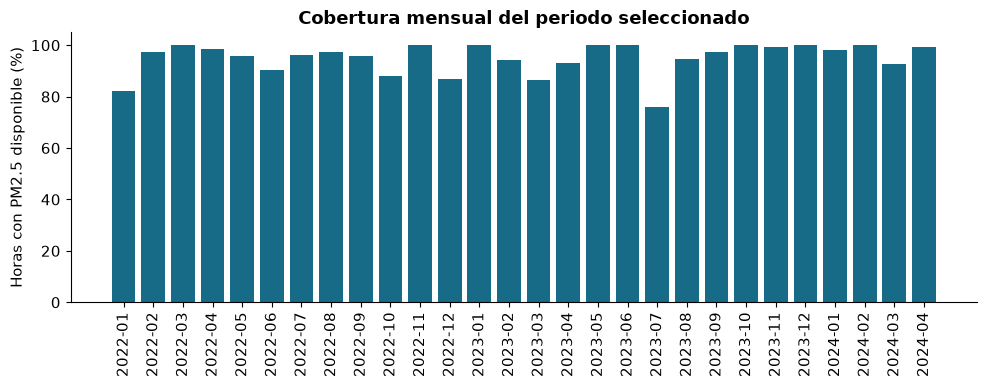

In [5]:
calidad = pd.DataFrame({'faltantes': df[raw.columns].isna().sum(),
                        'faltantes_pct': df[raw.columns].isna().mean()*100})
tabla(calidad, 'faltantes_por_variable')
contaminantes = df[['PM10', 'PM2_5', 'NO2']]
validacion = pd.DataFrame({'negativos': contaminantes.lt(0).sum(),
                           'ceros': contaminantes.eq(0).sum(),
                           'infinitos': np.isinf(contaminantes).sum()})
tabla(validacion, 'validacion_concentraciones')
mensual = s.resample('MS').agg(['size', 'count', 'mean', 'median'])
mensual.columns = ['horas_esperadas', 'mediciones', 'media', 'mediana']
mensual['faltantes'] = mensual.horas_esperadas - mensual.mediciones
mensual['cobertura_pct'] = 100*mensual.mediciones/mensual.horas_esperadas
tabla(mensual, 'resumen_mensual')
mask = s.isna()
grupos = mask.ne(mask.shift()).cumsum()
huecos = pd.DataFrame({'fecha': df.index, 'faltante': mask.to_numpy(), 'grupo': grupos.to_numpy()})
huecos = huecos.loc[huecos.faltante].groupby('grupo').agg(
    inicio=('fecha', 'min'), fin=('fecha', 'max'), horas=('fecha', 'size')).sort_values('horas', ascending=False)
tabla(huecos.head(10), 'mayores_interrupciones')
max_hueco = int(huecos.horas.max()) if len(huecos) else 0
display(Markdown(f'La mayor interrupción de PM2.5 dura **{max_hueco} horas**. '
                 'Las fechas de la tabla incluyen la primera y la última hora sin medición. '
                 'El CSV por sí solo no permite determinar la causa de estas interrupciones.'))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(mensual.index.strftime('%Y-%m'), mensual.cobertura_pct, color=COLOR)
ax.set(ylabel='Horas con PM2.5 disponible (%)', ylim=(0,105), title='Cobertura mensual del periodo seleccionado')
ax.tick_params(axis='x', rotation=90)
guardar(fig, '02_cobertura_mensual')

### Estructura de las interrupciones

El porcentaje agregado de faltantes describe mal el problema, porque las ausencias no están repartidas hora a hora sino concentradas en tramos. La distinción importa para el modelado: un faltante aislado apenas afecta al historial de las horas vecinas, mientras que un tramo largo invalida simultáneamente muchas respuestas y muchas ventanas de rezagos.

In [6]:
largos = huecos.horas
estructura = pd.DataFrame({'valor': {
    'Interrupciones': len(largos),
    'Horas faltantes en total': int(largos.sum()),
    'Mediana de horas por interrupción': float(largos.median()),
    'Interrupciones de 24 h o más': int((largos >= 24).sum()),
    'Horas dentro de esas interrupciones': int(largos[largos >= 24].sum()),
    'Porcentaje de los faltantes que concentran': 100*largos[largos >= 24].sum()/largos.sum(),
    'Mayor interrupción (horas)': int(largos.max())}})
tabla(estructura, 'estructura_interrupciones')
display(Markdown(
    f'Las {int(s.isna().sum()):,} horas sin medición se agrupan en **{len(largos)} interrupciones**, '
    f'con una mediana de **{largos.median():.0f} horas** cada una. '
    f'**{int((largos>=24).sum())} de ellas superan las 24 horas** y concentran '
    f'**{int(largos[largos>=24].sum())} horas**, es decir el '
    f'**{100*largos[largos>=24].sum()/largos.sum():.0f}%** de todos los faltantes. '
    'La pérdida de datos es, por tanto, un problema de episodios de parada y no de ruido disperso.'))

,valor
Interrupciones,47.000
Horas faltantes en total,1033.000
Mediana de horas por interrupción,11.000
Interrupciones de 24 h o más,12.000
Horas dentro de esas interrupciones,700.000
Porcentaje de los faltantes que concentran,67.764
Mayor interrupción (horas),126.000


Las 1,033 horas sin medición se agrupan en **47 interrupciones**, con una mediana de **11 horas** cada una. **12 de ellas superan las 24 horas** y concentran **700 horas**, es decir el **68%** de todos los faltantes. La pérdida de datos es, por tanto, un problema de episodios de parada y no de ruido disperso.

### Disponibilidad de los tres contaminantes

El mapa siguiente resume el **porcentaje de horas sin medición por mes** para PM10, PM2.5 y NO2. Cada columna representa un mes real, a diferencia de un mapa de filas del CSV. Sirve para reconocer interrupciones compartidas y para valorar cuánto contexto aportan los otros contaminantes. No se completan ni eliminan valores faltantes.

,PM10,PM2_5,NO2
fecha_hora,,,
2022-01-01,17.742,17.742,17.742
2022-02-01,2.530,2.530,1.339
2022-03-01,0.000,0.000,0.000
2022-04-01,1.528,1.528,1.667
2022-05-01,4.032,4.032,4.435
2022-06-01,9.722,9.722,10.833
2022-07-01,3.763,3.763,3.898
2022-08-01,2.688,2.688,2.823
2022-09-01,4.167,4.167,4.583


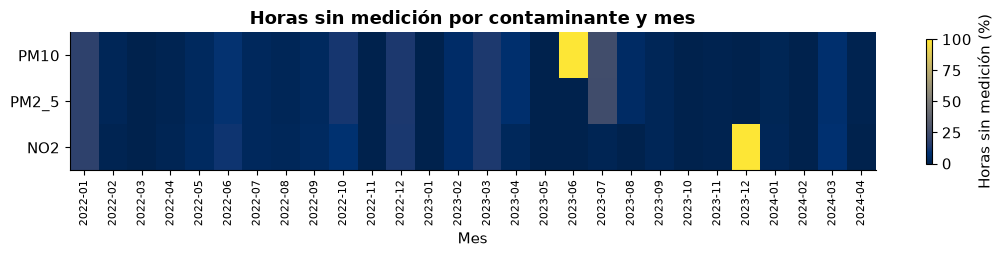

El mapa muestra disponibilidad, no niveles de contaminación. Un mes con alta proporción de faltantes tiene menos observaciones para calcular su resumen mensual.

In [7]:
cols_cont = ['PM10', 'PM2_5', 'NO2']
faltantes_mensuales = df[cols_cont].isna().resample('MS').mean().mul(100)
tabla(faltantes_mensuales, 'faltantes_mensuales_contaminantes_pct')

fig, ax = plt.subplots(figsize=(11, 2.7))
mapa = ax.imshow(faltantes_mensuales.T.to_numpy(), aspect='auto', vmin=0, vmax=100,
                 cmap='cividis', interpolation='nearest')
ax.set_yticks(range(3), cols_cont)
ax.set_xticks(range(len(faltantes_mensuales)), faltantes_mensuales.index.strftime('%Y-%m'),
              rotation=90, fontsize=8)
ax.set(title='Horas sin medición por contaminante y mes', xlabel='Mes')
fig.colorbar(mapa, ax=ax, label='Horas sin medición (%)', shrink=.9)
guardar(fig, '08_faltantes_contaminantes')

display(Markdown('El mapa muestra disponibilidad, no niveles de contaminación. '
                 'Un mes con alta proporción de faltantes tiene menos observaciones para calcular su resumen mensual.'))

### Señales atribuibles a la instrumentación

Dos patrones del mapa anterior no corresponden a paradas de la estación completa sino a sensores individuales, y conviene dejarlos registrados porque afectan a la interpretación del contexto, aunque no a la variable objetivo. Un tercero aparece al comparar los niveles medios de cada contaminante por año.

In [8]:
criticos = faltantes_mensuales[(faltantes_mensuales > 90).any(axis=1)]
tabla(criticos, 'meses_criticos_faltantes')
anual_cont = df[cols_cont].groupby(df.index.year).mean()
anual_cont.index.name = 'anio'
tabla(anual_cont, 'medias_anuales_contaminantes')
display(Markdown(
    'Los meses de la primera tabla tienen más del 90% de horas sin medición en un solo contaminante, '
    'mientras los otros dos siguen registrando con normalidad: apuntan a fallas de sensor, no a paradas de la estación.\n\n'
    f'En la segunda tabla destaca el comportamiento del NO2, cuya media pasa de '
    f'**{anual_cont.loc[2023, "NO2"]:.1f}** en 2023 a **{anual_cont.loc[2024, "NO2"]:.1f}** µg/m³ en 2024, '
    'en sentido contrario al de los dos materiales particulados, que descienden. '
    'Un cambio de nivel de esa magnitud y en dirección opuesta es compatible con una recalibración o un '
    'reemplazo de sensor. El CSV no permite confirmarlo. Se documenta como una reserva sobre el uso de NO2 '
    'como variable de contexto; no afecta a PM2.5, que es la variable objetivo.'))

,PM10,PM2_5,NO2
fecha_hora,,,
2023-06-01,99.306,0.0,0.000
2023-12-01,0.000,0.0,99.328


,PM10,PM2_5,NO2
anio,,,
2022,60.477,38.789,28.449
2023,34.852,23.826,23.159
2024,27.573,17.719,42.451


Los meses de la primera tabla tienen más del 90% de horas sin medición en un solo contaminante, mientras los otros dos siguen registrando con normalidad: apuntan a fallas de sensor, no a paradas de la estación.

En la segunda tabla destaca el comportamiento del NO2, cuya media pasa de **23.2** en 2023 a **42.5** µg/m³ en 2024, en sentido contrario al de los dos materiales particulados, que descienden. Un cambio de nivel de esa magnitud y en dirección opuesta es compatible con una recalibración o un reemplazo de sensor. El CSV no permite confirmarlo. Se documenta como una reserva sobre el uso de NO2 como variable de contexto; no afecta a PM2.5, que es la variable objetivo.

## 5. Estadísticas descriptivas
Se calculan sobre las concentraciones disponibles de PM2.5, sin imputación. Las observaciones son horarias y no independientes entre sí.

In [9]:
estadisticas = s.describe(percentiles=[.25, .5, .75, .95, .99]).to_frame('PM2.5')
estadisticas.loc['asimetria'] = s.skew()
tabla(estadisticas, 'estadisticas_pm25')
display(Markdown(f'La media es **{s.mean():.2f}** y la mediana **{s.median():.2f}** µg/m³. '
                 f'El 50% central de las mediciones está entre '
                 f'**{s.quantile(.25):.2f} y {s.quantile(.75):.2f}**. '
                 f'El rango observado va de **{s.min():.2f} a {s.max():.2f}**. '
                 f'La asimetría es **{s.skew():.2f}**: la media supera a la mediana porque una minoría de '
                 'horas con concentraciones altas arrastra el promedio. Es la manifestación, en un problema '
                 'de regresión, de lo que en clasificación sería un desbalance.'))

,PM2.5
count,19391.000
mean,29.290
std,18.166
min,3.432
25%,17.450
50%,24.500
75%,35.515
95%,65.305
99%,95.010
max,191.500


La media es **29.29** y la mediana **24.50** µg/m³. El 50% central de las mediciones está entre **17.45 y 35.52**. El rango observado va de **3.43 a 191.50**. La asimetría es **2.11**: la media supera a la mediana porque una minoría de horas con concentraciones altas arrastra el promedio. Es la manifestación, en un problema de regresión, de lo que en clasificación sería un desbalance.

### Controles de coherencia física

Antes de interpretar los valores altos conviene descartar que sean artefactos. Se comprueban tres cosas que un sensor defectuoso suele delatar: concentraciones imposibles de PM2.5 por encima de PM10 —la fracción fina está contenida en la gruesa—, rachas de valores idénticos consecutivos propias de un instrumento bloqueado, y saltos horarios desproporcionados.

In [10]:
pares_pm = df[['PM10', 'PM2_5']].dropna()
inconsistentes = int((pares_pm['PM2_5'] > pares_pm['PM10']).sum())
serie_obs = s.dropna()
cambios = serie_obs.ne(serie_obs.shift()).cumsum()
racha_max = int(serie_obs.groupby(cambios).size().max())
saltos = s.diff().abs()
SALTO_LIMITE = 50
controles = pd.DataFrame({'valor': {
    'Horas con PM2.5 mayor que PM10': inconsistentes,
    'Horas con ambas mediciones': len(pares_pm),
    'Racha máxima de valores idénticos consecutivos': racha_max,
    f'Saltos horarios mayores a {SALTO_LIMITE} µg/m³': int((saltos > SALTO_LIMITE).sum()),
    'Mayor salto horario observado': float(saltos.max())}})
tabla(controles, 'controles_coherencia')
tabla(saltos.nlargest(10).to_frame('salto_absoluto'), 'mayores_saltos_horarios')
display(Markdown(
    f'Ninguna de las **{len(pares_pm):,} horas** con ambas mediciones presenta PM2.5 por encima de PM10, '
    f'y la racha máxima de valores idénticos consecutivos es de **{racha_max}**, lo que descarta un sensor '
    'bloqueado. La racha se calcula sobre las mediciones disponibles en orden, sin exigir que sean horas '
    f'contiguas. Sí se observan **{int((saltos > SALTO_LIMITE).sum())} variaciones horarias superiores a '
    f'{SALTO_LIMITE} µg/m³**, con un máximo de **{saltos.max():.1f}**; quedan señaladas para revisión '
    'individual en la segunda etapa, sin descartarlas de antemano.'))

,valor
Horas con PM2.5 mayor que PM10,0.00
Horas con ambas mediciones,18671.00
Racha máxima de valores idénticos consecutivos,2.00
Saltos horarios mayores a 50 µg/m³,49.00
Mayor salto horario observado,121.02


,salto_absoluto
fecha_hora,
2022-05-22 12:00:00,121.02
2022-06-20 11:00:00,109.37
2022-06-21 10:00:00,102.96
2022-06-06 04:00:00,95.53
2022-12-01 11:00:00,91.19
2022-06-06 14:00:00,91.13
2022-05-29 13:00:00,83.10
2023-02-28 14:00:00,79.94
2022-06-26 16:00:00,79.05


Ninguna de las **18,671 horas** con ambas mediciones presenta PM2.5 por encima de PM10, y la racha máxima de valores idénticos consecutivos es de **2**, lo que descarta un sensor bloqueado. La racha se calcula sobre las mediciones disponibles en orden, sin exigir que sean horas contiguas. Sí se observan **49 variaciones horarias superiores a 50 µg/m³**, con un máximo de **121.0**; quedan señaladas para revisión individual en la segunda etapa, sin descartarlas de antemano.

## 6. Distribución y posibles valores atípicos
La regla de 1,5 veces el rango intercuartílico (IQR) identifica valores para revisar; no prueba errores de medición. No se elimina ninguna observación por esta regla.

,valor
Limite inferior IQR,-9.648
Limite superior IQR,62.613
Mediciones señaladas,1126.000
Porcentaje de disponibles,5.807


,PM2.5
fecha_hora,
2022-08-14 13:00:00,191.5
2022-05-22 11:00:00,191.4
2022-05-29 13:00:00,181.4
2022-05-24 13:00:00,177.4
2022-07-02 11:00:00,176.5
2022-05-29 14:00:00,175.0
2022-04-29 13:00:00,170.7
2022-05-25 14:00:00,168.5
2022-05-22 10:00:00,166.9


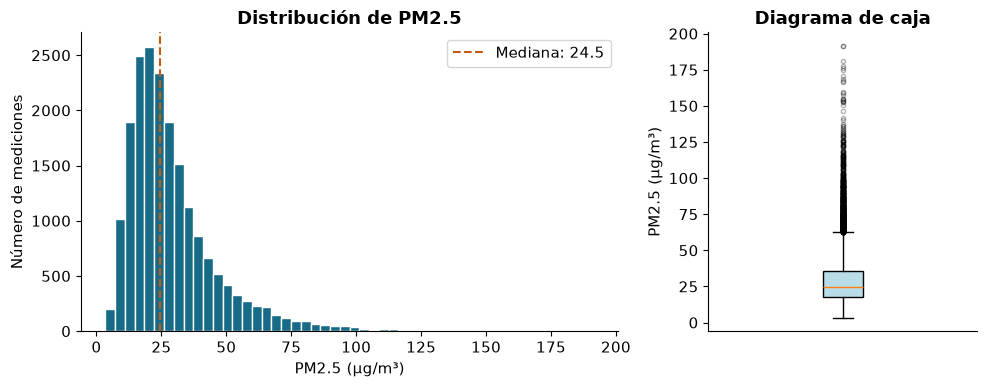

La regla IQR señala **1,126 mediciones** (**5.81%** de las disponibles). Se conservan porque podrían corresponder a episodios reales. Para clasificarlas como errores haría falta información de validación o mantenimiento de la estación.

In [11]:
q1, q3 = s.quantile([.25, .75])
iqr = q3-q1
inferior, superior = q1-1.5*iqr, q3+1.5*iqr
atipicos = s.lt(inferior) | s.gt(superior)
tabla(pd.DataFrame({'valor': {'Limite inferior IQR': inferior, 'Limite superior IQR': superior,
    'Mediciones señaladas': atipicos.sum(), 'Porcentaje de disponibles': 100*atipicos.sum()/s.count()}}), 'revision_atipicos')
tabla(s.nlargest(10).to_frame('PM2.5'), 'mayores_concentraciones')
fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios':[2,1]})
axes[0].hist(s.dropna(), bins=50, color=COLOR, edgecolor='white')
axes[0].axvline(s.median(), color=ACENTO, linestyle='--', label=f'Mediana: {s.median():.1f}')
axes[0].set(xlabel=UNIDAD, ylabel='Número de mediciones', title='Distribución de PM2.5')
axes[0].legend()
axes[1].boxplot(s.dropna(), patch_artist=True, boxprops={'facecolor':'#B9DDE8'},
                flierprops={'markersize':3, 'alpha':.3})
axes[1].set(ylabel=UNIDAD, xticks=[], title='Diagrama de caja')
guardar(fig, '03_distribucion_pm25')
display(Markdown(f'La regla IQR señala **{atipicos.sum():,} mediciones** '
                 f'(**{100*atipicos.sum()/s.count():.2f}%** de las disponibles). '
                 'Se conservan porque podrían corresponder a episodios reales. '
                 'Para clasificarlas como errores haría falta información de validación o mantenimiento de la estación.'))

### ¿Dónde ocurren los valores extremos?

Contarlos no basta para decidir si conservarlos. Si se repartieran al azar en el tiempo, serían un argumento a favor del ruido instrumental; si se concentran en periodos y horas concretos, lo son a favor de episodios reales. Los tres paneles siguientes responden esa pregunta por año, por mes y por hora del día.

,mediciones,pct_del_total
anio,,
2022,1070,95.027
2023,42,3.730
2024,14,1.243


,por_mes
fecha_hora,
1,18
2,11
3,13
4,55
5,189
6,189
7,156
8,220
9,106


,por_hora
fecha_hora,
0,8
1,13
2,22
3,28
4,41
5,44
6,59
7,54
8,60


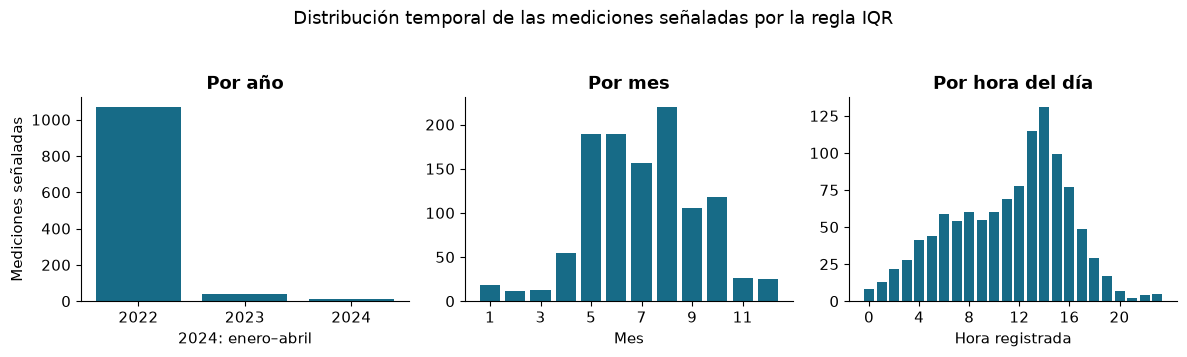

De las **1,126 mediciones señaladas**, **1,070** (**95%**) corresponden a 2022. Dentro del año se concentran entre mayo y octubre, y dentro del día entre las 12:00 y las 16:00, franja que coincide con la de mayor mediana horaria. Un ruido instrumental no reproduciría esta estructura estacional y horaria, de modo que la evidencia disponible favorece interpretarlas como episodios reales de contaminación. Se conservan.

In [12]:
altos = s[atipicos.fillna(False)]
por_anio = altos.groupby(altos.index.year).size().rename('mediciones').to_frame()
por_anio['pct_del_total'] = 100*por_anio.mediciones/len(altos)
por_anio.index.name = 'anio'
tabla(por_anio, 'atipicos_por_anio')
por_mes = altos.groupby(altos.index.month).size().reindex(range(1,13), fill_value=0)
por_hora = altos.groupby(altos.index.hour).size().reindex(range(24), fill_value=0)
tabla(pd.DataFrame({'por_mes': por_mes}), 'atipicos_por_mes')
tabla(pd.DataFrame({'por_hora': por_hora}), 'atipicos_por_hora')

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
axes[0].bar(por_anio.index.astype(str), por_anio.mediciones, color=COLOR)
axes[0].set(title='Por año', ylabel='Mediciones señaladas')
axes[0].set_xlabel('2024: enero–abril')
axes[1].bar(por_mes.index, por_mes.to_numpy(), color=COLOR)
axes[1].set(title='Por mes', xlabel='Mes', xticks=range(1,13,2))
axes[2].bar(por_hora.index, por_hora.to_numpy(), color=COLOR)
axes[2].set(title='Por hora del día', xlabel='Hora registrada', xticks=range(0,24,4))
fig.suptitle('Distribución temporal de las mediciones señaladas por la regla IQR', y=1.04)
guardar(fig, '11_atipicos_calendario')

anio_top = int(por_anio.mediciones.idxmax())
display(Markdown(
    f'De las **{len(altos):,} mediciones señaladas**, **{int(por_anio.loc[anio_top, "mediciones"]):,}** '
    f'(**{por_anio.loc[anio_top, "pct_del_total"]:.0f}%**) corresponden a {anio_top}. '
    f'Dentro del año se concentran entre mayo y octubre, y dentro del día entre las '
    f'{int(por_hora.idxmax())-2:02d}:00 y las {int(por_hora.idxmax())+2:02d}:00, franja que coincide con la de '
    'mayor mediana horaria. Un ruido instrumental no reproduciría esta estructura estacional y horaria, '
    'de modo que la evidencia disponible favorece interpretarlas como episodios reales de contaminación. '
    'Se conservan.'))

### Comparación con los umbrales de referencia

Con la unidad confirmada en µg/m³ es posible situar las concentraciones frente a la normativa. Tanto el Estándar de Calidad Ambiental peruano (50 µg/m³) como la guía de la OMS (15 µg/m³) están definidos sobre promedios de **24 horas**, no sobre mediciones horarias, de modo que la comparación se hace únicamente sobre medias diarias calculadas en días con al menos 18 de las 24 horas medidas.

In [13]:
COBERTURA_DIA = 18
diario_full = s.resample('D').agg(['count', 'mean', 'median'])
diario_valido = diario_full[diario_full['count'] >= COBERTURA_DIA]
supera_eca = diario_valido['mean'] > ECA_DIARIO
supera_oms = diario_valido['mean'] > OMS_DIARIO
umbrales = pd.DataFrame({'valor': {
    'Días con cobertura suficiente': len(diario_valido),
    'Días sobre el ECA peruano (50 µg/m³)': int(supera_eca.sum()),
    'Porcentaje sobre el ECA': 100*supera_eca.mean(),
    'Días sobre la guía OMS (15 µg/m³)': int(supera_oms.sum()),
    'Porcentaje sobre la guía OMS': 100*supera_oms.mean(),
    'Media diaria máxima': float(diario_valido['mean'].max())}})
tabla(umbrales, 'superacion_umbrales_diarios')
display(Markdown(
    f'De los **{len(diario_valido):,} días** con cobertura suficiente, **{int(supera_oms.sum()):,}** '
    f'(**{100*supera_oms.mean():.0f}%**) superan la guía diaria de la OMS y **{int(supera_eca.sum())}** '
    f'(**{100*supera_eca.mean():.1f}%**) superan el ECA peruano, más laxo. '
    'La distancia entre ambas cifras refleja sobre todo la diferencia entre los dos umbrales. '
    'Esto sitúa el problema: no se trata de un contaminante ocasionalmente elevado, sino de una exposición '
    'que supera la recomendación internacional la mayor parte de los días, lo que da sentido a disponer de '
    'un pronóstico a corto plazo. Los días sin cobertura suficiente quedan fuera del cálculo y no se '
    'reemplazan por ningún valor.'))

,valor
Días con cobertura suficiente,795.000
Días sobre el ECA peruano (50 µg/m³),82.000
Porcentaje sobre el ECA,10.314
Días sobre la guía OMS (15 µg/m³),739.000
Porcentaje sobre la guía OMS,92.956
Media diaria máxima,94.854


De los **795 días** con cobertura suficiente, **739** (**93%**) superan la guía diaria de la OMS y **82** (**10.3%**) superan el ECA peruano, más laxo. La distancia entre ambas cifras refleja sobre todo la diferencia entre los dos umbrales. Esto sitúa el problema: no se trata de un contaminante ocasionalmente elevado, sino de una exposición que supera la recomendación internacional la mayor parte de los días, lo que da sentido a disponer de un pronóstico a corto plazo. Los días sin cobertura suficiente quedan fuera del cálculo y no se reemplazan por ningún valor.

## 7. Comportamiento temporal
Se muestran las mediciones horarias con sus huecos. La mediana diaria se dibuja solo en días con al menos 18 de 24 mediciones (75%); es un criterio descriptivo de este análisis, no una norma del proveedor.

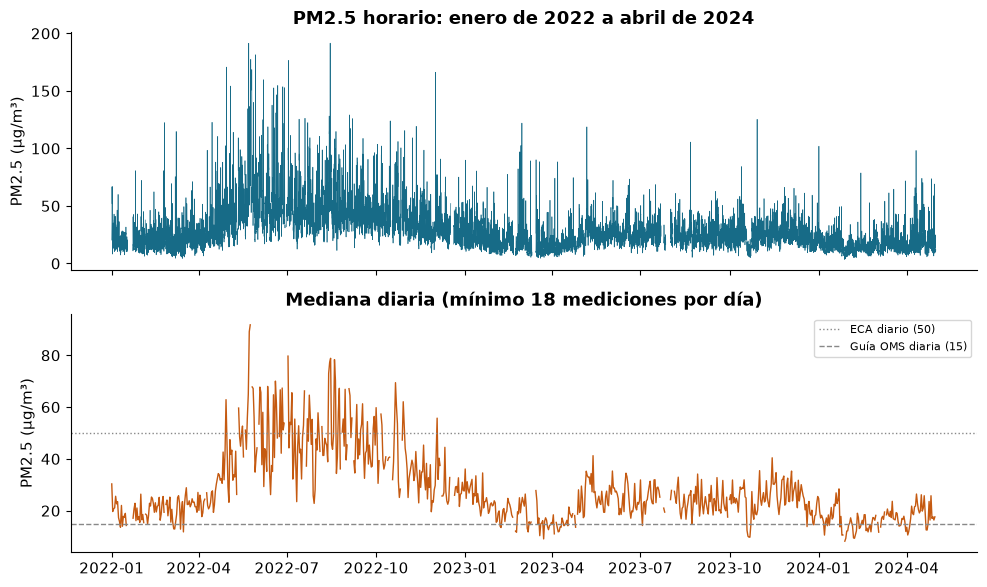

,count,mean,median,q25,q75,horas_esperadas,cobertura_pct
fecha_hora,,,,,,,
0,817,23.446,20.410,15.560,28.750,851,96.005
1,816,26.102,22.880,17.620,30.935,851,95.887
2,807,28.420,25.120,19.430,33.400,851,94.830
3,798,29.784,26.240,20.398,34.380,851,93.772
4,797,30.107,26.120,19.980,34.780,851,93.655
5,798,30.118,25.690,19.060,35.465,851,93.772
6,798,30.266,25.030,18.465,35.258,851,93.772
7,798,29.820,24.400,18.038,34.378,851,93.772
8,797,29.830,24.370,17.880,34.940,851,93.655


,count,mean,median,q25,q75,horas_esperadas,cobertura_pct
Lun,2763,28.441,23.590,16.920,34.205,2928,94.365
Mar,2824,29.348,24.765,17.620,35.963,2928,96.448
Mié,2711,27.732,23.940,16.780,33.830,2904,93.354
Jue,2792,28.621,24.225,17.548,35.002,2904,96.143
Vie,2741,29.897,25.410,18.030,35.520,2904,94.387
Sáb,2792,31.185,25.735,18.108,37.942,2928,95.355
Dom,2768,29.769,24.250,17.085,36.190,2928,94.536


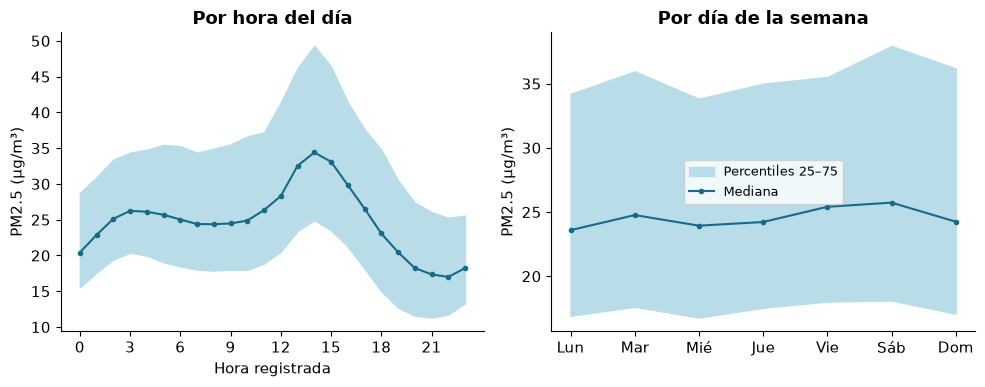

La mayor mediana horaria aparece a las **14:00** y la menor a las **22:00**. Las bandas muestran dispersión de las mediciones, no intervalos de confianza. Estas diferencias son descriptivas: no establecen causalidad ni demuestran una mejora predictiva.

In [14]:
diario = diario_full.copy()
diario['mediana_con_cobertura'] = diario['median'].where(diario['count'] >= COBERTURA_DIA)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(s.index, s, linewidth=.45, color=COLOR)
axes[0].set(ylabel=UNIDAD, title='PM2.5 horario: enero de 2022 a abril de 2024')
axes[1].plot(diario.index, diario.mediana_con_cobertura, linewidth=1, color=ACENTO)
axes[1].axhline(ECA_DIARIO, color='#888888', linestyle=':', linewidth=1, label=f'ECA diario ({ECA_DIARIO})')
axes[1].axhline(OMS_DIARIO, color='#888888', linestyle='--', linewidth=1, label=f'Guía OMS diaria ({OMS_DIARIO})')
axes[1].set(ylabel=UNIDAD, title='Mediana diaria (mínimo 18 mediciones por día)')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
guardar(fig, '04_serie_temporal')

hora = s.groupby(s.index.hour).agg(['count','mean','median'])
hora['q25'] = s.groupby(s.index.hour).quantile(.25)
hora['q75'] = s.groupby(s.index.hour).quantile(.75)
hora['horas_esperadas'] = s.groupby(s.index.hour).size()
hora['cobertura_pct'] = 100*hora['count']/hora.horas_esperadas
tabla(hora, 'patron_horario')
semana = s.groupby(s.index.dayofweek).agg(['count','mean','median'])
semana['q25'] = s.groupby(s.index.dayofweek).quantile(.25)
semana['q75'] = s.groupby(s.index.dayofweek).quantile(.75)
semana['horas_esperadas'] = s.groupby(s.index.dayofweek).size()
semana['cobertura_pct'] = 100*semana['count']/semana.horas_esperadas
semana.index = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
tabla(semana, 'patron_semanal')
fig, axes = plt.subplots(1,2,figsize=(10,4))
for ax, t, x, titulo in [(axes[0],hora,np.arange(24),'Por hora del día'),
                         (axes[1],semana,np.arange(7),'Por día de la semana')]:
    ax.fill_between(x,t.q25.to_numpy(),t.q75.to_numpy(),color='#B9DDE8',label='Percentiles 25–75')
    ax.plot(x,t['median'],color=COLOR,marker='o',markersize=3,label='Mediana')
    ax.set(title=titulo,ylabel=UNIDAD)
axes[0].set_xticks(np.arange(0,24,3)); axes[0].set_xlabel('Hora registrada')
axes[1].set_xticks(np.arange(7),semana.index);axes[1].legend(fontsize=9)
guardar(fig, '05_patrones_calendario')
display(Markdown(f'La mayor mediana horaria aparece a las **{hora["median"].idxmax():02d}:00** '
                 f'y la menor a las **{hora["median"].idxmin():02d}:00**. '
                 'Las bandas muestran dispersión de las mediciones, no intervalos de confianza. '
                 'Estas diferencias son descriptivas: no establecen causalidad ni demuestran una mejora predictiva.'))

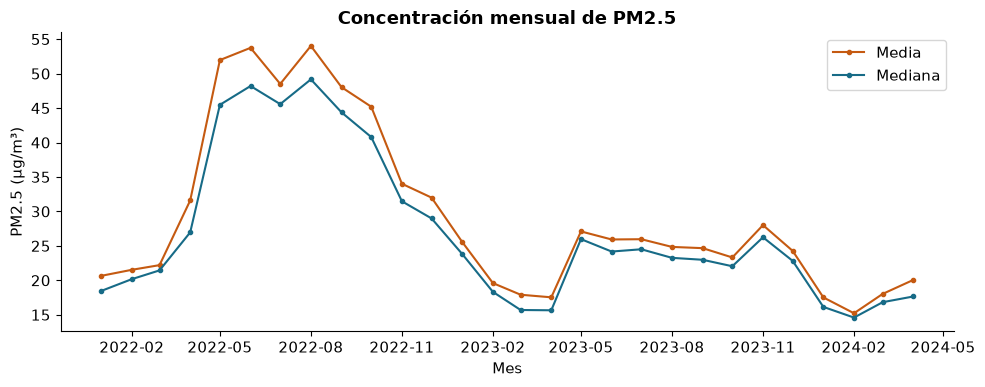

Cada punto resume las mediciones disponibles del mes. Debe leerse junto con la cobertura mensual: los meses tienen distinta cantidad de observaciones. Dos años completos y cuatro meses adicionales no bastan para afirmar que un patrón estacional se repetirá en otros periodos.

In [15]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(mensual.index,mensual['media'],label='Media',color=ACENTO,marker='o',markersize=3)
ax.plot(mensual.index,mensual['mediana'],label='Mediana',color=COLOR,marker='o',markersize=3)
ax.set(title='Concentración mensual de PM2.5',ylabel=UNIDAD,xlabel='Mes')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend()
guardar(fig, '06_resumen_mensual')
display(Markdown('Cada punto resume las mediciones disponibles del mes. Debe leerse junto con la cobertura mensual: '
                 'los meses tienen distinta cantidad de observaciones. Dos años completos y cuatro meses adicionales '
                 'no bastan para afirmar que un patrón estacional se repetirá en otros periodos.'))

### Cambio de nivel entre años

La serie mensual sugiere algo más que estacionalidad: el nivel general desciende a lo largo del periodo. Conviene cuantificarlo, porque tiene una consecuencia directa sobre el diseño experimental de la segunda etapa. Si los años no son intercambiables, una partición cronológica coloca el entrenamiento y la prueba en regímenes distintos de concentración.

,mediciones,media,mediana,desviacion,maximo
anio,,,,,
2022,8236,38.789,33.765,21.915,191.5
2023,8326,23.826,22.410,10.159,125.3
2024,2829,17.719,16.100,8.706,101.9


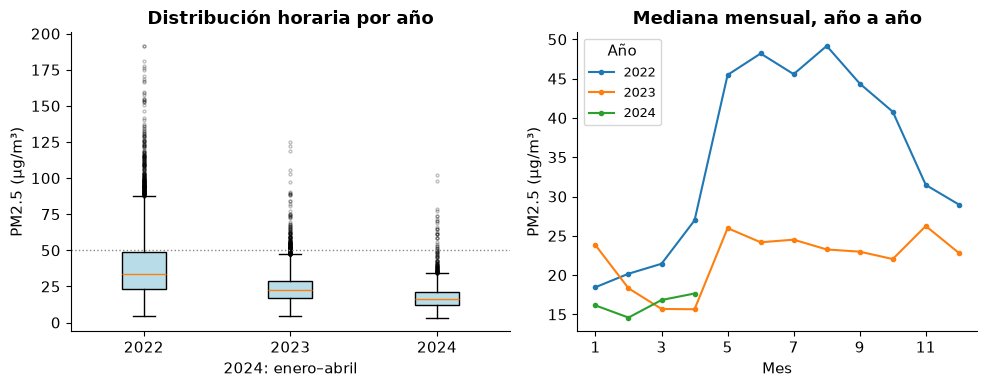

La media anual pasa de **38.8** en 2022 a **23.8** en 2023 y **17.7** µg/m³ en el tramo de 2024, con medianas de **33.8**, **22.4** y **16.1**. Parte del descenso de 2024 es estacional, porque solo abarca enero–abril, meses de menor concentración; el panel derecho lo muestra al superponer las medianas mensuales de cada año. Pero 2022 y 2023 son dos calendarios completos, y 2022 supera a 2023 en once de los doce meses: enero es la única excepción. La separación se concentra entre mayo y octubre, con unos 22 µg/m³ de diferencia en la mediana mensual, de modo que el calendario por sí solo no explica la caída. 

Consecuencia para la segunda etapa: una partición cronológica entrena en un régimen de concentraciones más altas del que evalúa. El error absoluto (RMSE o MAE) no es comparable entre tramos, porque una misma magnitud de error representa un desempeño relativo distinto. Las métricas deberán reportarse desagregadas por año y cada tramo deberá compararse contra su propia referencia de persistencia. No se altera la selección del periodo por este motivo: reducirlo a un solo año dejaría muy pocos datos.

In [16]:
anual = s.groupby(s.index.year).agg(['count','mean','median','std','max'])
anual.columns = ['mediciones','media','mediana','desviacion','maximo']
anual.index.name = 'anio'
tabla(anual, 'resumen_anual')

fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios':[1.1,1]})
datos_box = [s[s.index.year == a].dropna().to_numpy() for a in anual.index]
bp = axes[0].boxplot(datos_box, patch_artist=True, tick_labels=[str(a) for a in anual.index],
                     flierprops={'markersize':2,'alpha':.25})
for caja in bp['boxes']:
    caja.set_facecolor('#B9DDE8')
axes[0].axhline(ECA_DIARIO, color='#888888', linestyle=':', linewidth=1)
axes[0].set(ylabel=UNIDAD, title='Distribución horaria por año')
axes[0].set_xlabel('2024: enero–abril')
for a in anual.index:
    sub = s[s.index.year == a]
    axes[1].plot(sub.groupby(sub.index.month).median().index,
                 sub.groupby(sub.index.month).median().to_numpy(),
                 marker='o', markersize=3, label=str(a))
axes[1].set(xlabel='Mes', ylabel=UNIDAD, title='Mediana mensual, año a año', xticks=range(1,13,2))
axes[1].legend(fontsize=9, title='Año')
guardar(fig, '12_distribucion_anual')

display(Markdown(
    f'La media anual pasa de **{anual.loc[2022,"media"]:.1f}** en 2022 a **{anual.loc[2023,"media"]:.1f}** en 2023 '
    f'y **{anual.loc[2024,"media"]:.1f}** µg/m³ en el tramo de 2024, con medianas de '
    f'**{anual.loc[2022,"mediana"]:.1f}**, **{anual.loc[2023,"mediana"]:.1f}** y **{anual.loc[2024,"mediana"]:.1f}**. '
    'Parte del descenso de 2024 es estacional, porque solo abarca enero–abril, meses de menor concentración; '
    'el panel derecho lo muestra al superponer las medianas mensuales de cada año. Pero 2022 y 2023 son dos '
    'calendarios completos, y 2022 supera a 2023 en once de los doce meses: enero es la única excepción. '
    'La separación se concentra entre mayo y octubre, con unos 22 µg/m³ de diferencia en la mediana mensual, '
    'de modo que el calendario por sí solo no explica la caída. '
    '\n\nConsecuencia para la segunda etapa: una partición cronológica entrena en un régimen de concentraciones '
    'más altas del que evalúa. El error absoluto (RMSE o MAE) no es comparable entre tramos, porque una misma '
    'magnitud de error representa un desempeño relativo distinto. Las métricas deberán reportarse desagregadas '
    'por año y cada tramo deberá compararse contra su propia referencia de persistencia. No se altera la '
    'selección del periodo por este motivo: reducirlo a un solo año dejaría muy pocos datos.'))

### Relación entre horas consecutivas
Al mantener la rejilla completa, `shift(-1)` corresponde exactamente a una hora después. Se descartan pares incompletos solo para este gráfico; la serie original conserva sus faltantes. Esta relación describe dependencia temporal, no es una evaluación de modelos.

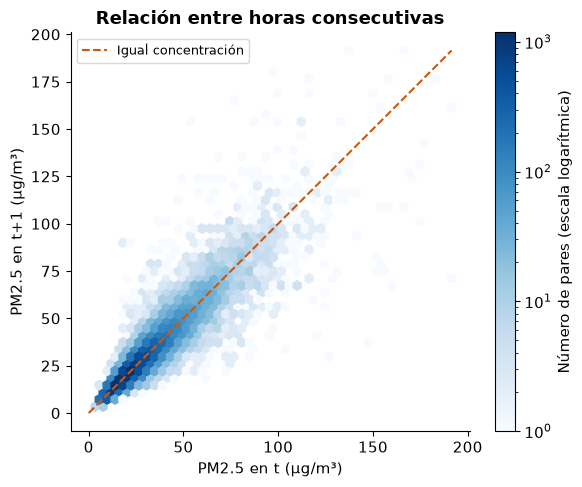

Hay **19,343 pares horarios completos**. La correlación de Pearson es **0.912**. Esta dependencia justifica comparar los modelos con la persistencia (usar el valor de la hora actual como pronóstico de la siguiente), sin anticipar cuál funcionará mejor.

In [17]:
pares = pd.DataFrame({'PM25_t':s,'PM25_t_mas_1':s.shift(-1)}).dropna()
correlacion = pares.PM25_t.corr(pares.PM25_t_mas_1)
fig, ax = plt.subplots(figsize=(6,5))
hb = ax.hexbin(pares.PM25_t,pares.PM25_t_mas_1,gridsize=45,mincnt=1,bins='log',cmap='Blues')
lim = max(pares.max())
ax.plot([0,lim],[0,lim],'--',color=ACENTO,label='Igual concentración')
fig.colorbar(hb,ax=ax,label='Número de pares (escala logarítmica)')
ax.set(xlabel='PM2.5 en t (µg/m³)',ylabel='PM2.5 en t+1 (µg/m³)',
       title='Relación entre horas consecutivas')
ax.legend(fontsize=9)
guardar(fig, '07_horas_consecutivas')
display(Markdown(f'Hay **{len(pares):,} pares horarios completos**. La correlación de Pearson es '
                 f'**{correlacion:.3f}**. Esta dependencia justifica comparar los modelos con la persistencia '
                 '(usar el valor de la hora actual como pronóstico de la siguiente), sin anticipar cuál funcionará mejor.'))

### Autocorrelación: ¿cuántos rezagos aportan información?

La correlación a un paso responde solo por la hora inmediatamente anterior. Para decidir cuántos rezagos incorporar como variables de entrada hace falta mirar la dependencia a distancias mayores.

Dado que la serie tiene interrupciones, no se aplica un estimador que suponga la serie completa. Para cada rezago $k$ se calcula la correlación de Pearson entre $PM_{2.5}(t)$ y $PM_{2.5}(t-k)$ **usando únicamente las horas en que ambos valores están disponibles**, de modo que cada punto se apoya en un número de pares distinto que también se reporta. La correlación parcial se deriva de esa secuencia por el algoritmo de Durbin–Levinson: estima el aporte propio de cada rezago una vez descontado el de los anteriores.

,correlacion,correlacion_parcial,pares_disponibles
rezago_horas,,,
1,0.912,0.912,19343
2,0.800,-0.184,19297
3,0.713,0.100,19251
4,0.640,0.000,19206
5,0.580,0.028,19161
6,0.534,0.050,19117
7,0.502,0.051,19082
8,0.482,0.050,19046
9,0.471,0.062,19015


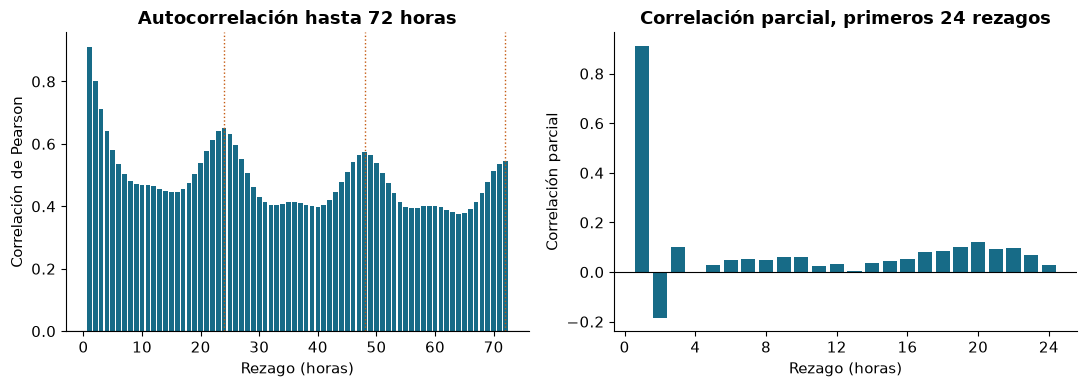

La correlación cae de **0.912** en el primer rezago a **0.464** en el rezago 12, y vuelve a subir hasta **0.651** alrededor del rezago 24: es la periodicidad diaria, visible de nuevo cerca de las 48 horas. La correlación parcial, en cambio, se concentra casi por completo en el primer rezago (**0.912**), con un aporte propio ya pequeño en el segundo (**-0.184**) y prácticamente nulo después.

La lectura para el diseño de variables es doble. Los rezagos inmediatos son los que aportan información propia, de modo que una ventana corta de tres a seis horas debería capturar casi toda la dependencia de corto alcance. El repunte a 24 horas, en cambio, no representa información nueva sino el ciclo diario, que puede recogerse de forma más económica con variables de calendario que con veinticuatro rezagos. Cuál de las dos opciones funciona mejor es precisamente la segunda pregunta de investigación, y se responde comparando modelos, no mirando este gráfico.

In [18]:
K_MAX = 72
acf = pd.Series({k: s.corr(s.shift(k)) for k in range(1, K_MAX+1)}, name='correlacion')
pares_por_rezago = pd.Series({k: int((s.notna() & s.shift(k).notna()).sum()) for k in range(1, K_MAX+1)},
                             name='pares_disponibles')

def pacf_durbin_levinson(rho, K):
    # rho[0] = 1 y rho[k] = correlación de Pearson al rezago k.
    phi = np.zeros((K+1, K+1))
    parciales = np.full(K+1, np.nan)
    phi[1, 1] = rho[1]
    parciales[1] = rho[1]
    for k in range(2, K+1):
        num = rho[k] - sum(phi[k-1, j]*rho[k-j] for j in range(1, k))
        den = 1 - sum(phi[k-1, j]*rho[j] for j in range(1, k))
        if abs(den) < 1e-12:
            break
        phi[k, k] = num/den
        parciales[k] = phi[k, k]
        for j in range(1, k):
            phi[k, j] = phi[k-1, j] - phi[k, k]*phi[k-1, k-j]
    return parciales[1:]

rho = np.concatenate([[1.0], acf.to_numpy()])
pacf = pd.Series(pacf_durbin_levinson(rho, K_MAX), index=acf.index, name='correlacion_parcial')
assert np.nanmax(np.abs(pacf)) <= 1, 'Correlaciones parciales fuera de rango: revisar la estimación.'

autocorr = pd.concat([acf, pacf, pares_por_rezago], axis=1)
autocorr.index.name = 'rezago_horas'
tabla(autocorr.head(30), 'autocorrelacion')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(acf.index, acf.to_numpy(), color=COLOR, width=.8)
for marca in (24, 48, 72):
    axes[0].axvline(marca, color=ACENTO, linestyle=':', linewidth=1)
axes[0].axhline(0, color='black', linewidth=.8)
axes[0].set(xlabel='Rezago (horas)', ylabel='Correlación de Pearson',
            title=f'Autocorrelación hasta {K_MAX} horas')
axes[1].bar(pacf.index[:24], pacf.to_numpy()[:24], color=COLOR, width=.8)
axes[1].axhline(0, color='black', linewidth=.8)
axes[1].set(xlabel='Rezago (horas)', ylabel='Correlación parcial',
            title='Correlación parcial, primeros 24 rezagos', xticks=range(0, 25, 4))
guardar(fig, '13_autocorrelacion')

repunte = int(acf.loc[20:28].idxmax())
display(Markdown(
    f'La correlación cae de **{acf[1]:.3f}** en el primer rezago a **{acf[12]:.3f}** en el rezago 12, '
    f'y vuelve a subir hasta **{acf[repunte]:.3f}** alrededor del rezago {repunte}: es la periodicidad diaria, '
    'visible de nuevo cerca de las 48 horas. La correlación parcial, en cambio, se concentra casi por completo '
    f'en el primer rezago (**{pacf[1]:.3f}**), con un aporte propio ya pequeño en el segundo (**{pacf[2]:.3f}**) '
    'y prácticamente nulo después.\n\n'
    'La lectura para el diseño de variables es doble. Los rezagos inmediatos son los que aportan información '
    'propia, de modo que una ventana corta de tres a seis horas debería capturar casi toda la dependencia de '
    'corto alcance. El repunte a 24 horas, en cambio, no representa información nueva sino el ciclo diario, '
    'que puede recogerse de forma más económica con variables de calendario que con veinticuatro rezagos. '
    'Cuál de las dos opciones funciona mejor es precisamente la segunda pregunta de investigación, y se '
    'responde comparando modelos, no mirando este gráfico.'))

### Contexto: PM10 y NO2 en la misma estación

PM10 y NO2 ayudan a describir el entorno de medición, aunque **la variable objetivo sigue siendo PM2.5**. La figura presenta la media mensual de cada contaminante en paneles separados, calculada únicamente con sus horas observadas. Cada panel tiene su propia escala vertical, por lo que la altura visual de las curvas no compara magnitudes entre contaminantes. La cobertura mensual debe revisarse junto con las medias. No se incluyen registros posteriores a abril de 2024.

,PM10,PM2_5,NO2
fecha_hora,,,
2022-01-01,40.252,20.648,24.045
2022-02-01,43.180,21.525,27.318
2022-03-01,39.649,22.202,28.432
2022-04-01,51.517,31.589,31.934
2022-05-01,80.154,51.965,34.105
2022-06-01,78.215,53.741,29.780
2022-07-01,67.575,48.500,28.055
2022-08-01,76.877,54.020,29.099
2022-09-01,70.221,48.028,29.781


,PM10,PM2_5,NO2
fecha_hora,,,
2022-01-01,612,612,612
2022-02-01,655,655,663
2022-03-01,744,744,744
2022-04-01,709,709,708
2022-05-01,714,714,711
2022-06-01,650,650,642
2022-07-01,716,716,715
2022-08-01,724,724,723
2022-09-01,690,690,687


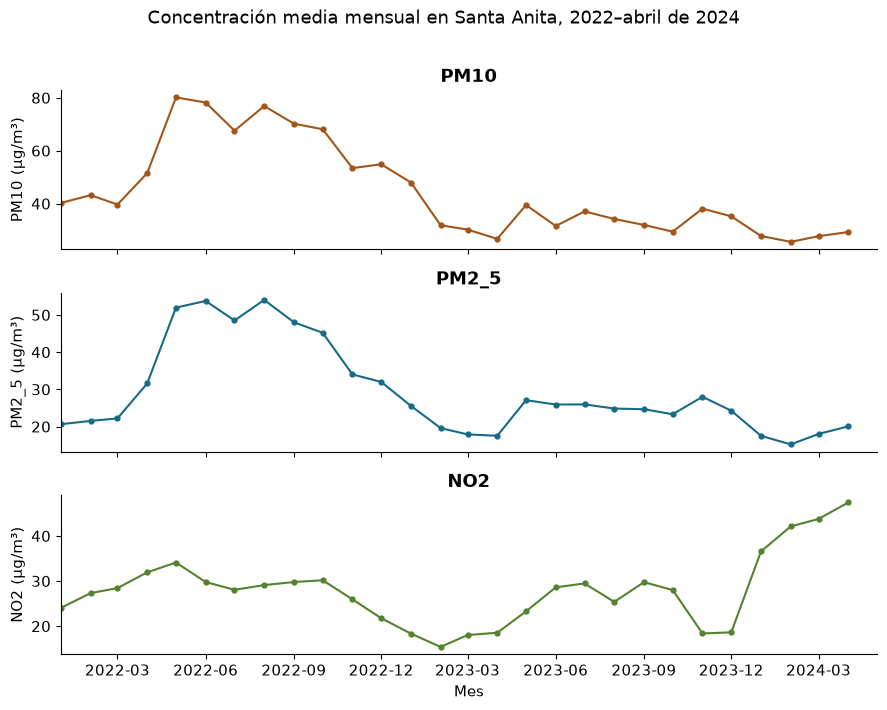

La comparación describe cómo cambian los tres contaminantes en el tiempo. Su evolución no identifica las causas de los cambios ni convierte a PM10 o NO2 en predictores de la siguiente hora dentro del diseño actual. El tramo final de NO2 debe leerse junto con la reserva sobre instrumentación de la sección 4.

In [19]:
promedios = df[cols_cont].resample('MS').mean()
conteos = df[cols_cont].resample('MS').count()
tabla(promedios, 'promedios_mensuales_contaminantes')
tabla(conteos, 'mediciones_mensuales_contaminantes')

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
colores = {'PM10':'#A25518', 'PM2_5':COLOR, 'NO2':'#54822E'}
for ax, variable in zip(axes, cols_cont):
    ax.plot(promedios.index, promedios[variable], marker='o', markersize=3.5,
            linewidth=1.5, color=colores[variable])
    ax.set(ylabel=f'{variable} (µg/m³)', title=variable)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].set_xlabel('Mes')
axes[-1].set_xlim(INICIO, FIN)
fig.suptitle('Concentración media mensual en Santa Anita, 2022–abril de 2024', y=1.01)
guardar(fig, '09_promedios_mensuales_contaminantes')

display(Markdown('La comparación describe cómo cambian los tres contaminantes en el tiempo. '
                 'Su evolución no identifica las causas de los cambios ni convierte a PM10 o NO2 '
                 'en predictores de la siguiente hora dentro del diseño actual. '
                 'El tramo final de NO2 debe leerse junto con la reserva sobre instrumentación de la sección 4.'))

### Correlación entre contaminantes medidos en la misma hora

La matriz utiliza **correlación de Pearson** y, para cada par, solo las horas en que ambos contaminantes tienen medición. Los tamaños de muestra pueden ser distintos. Se analizan los tres contaminantes; no se incluyen hora ni día de la semana como números lineales, pues son variables cíclicas. Una correlación simultánea alta no establece causalidad ni predice la concentración de la hora siguiente.

,PM10,PM2_5,NO2
PM10,1.000,0.937,0.107
PM2_5,0.937,1.000,0.076
NO2,0.107,0.076,1.000


,PM10,PM2_5,NO2
PM10,18671,18671,17900
PM2_5,18671,19391,18620
NO2,17900,18620,18894


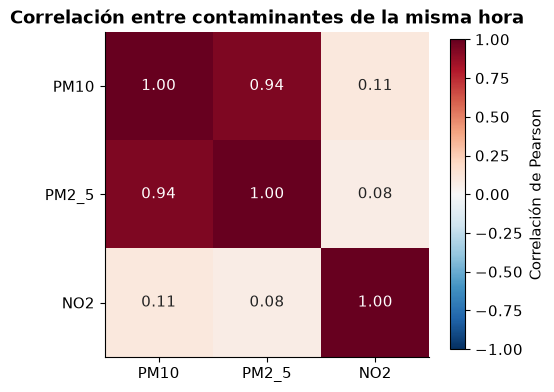

PM10 y PM2.5 presentan una correlación de **0.937** en **18,671 horas compartidas**. La correlación entre NO2 y PM2.5 es **0.076** en **18,620 horas compartidas**. En el proyecto, esto es contexto descriptivo; el aporte predictivo del calendario se evaluará con modelos y periodos posteriores.

In [20]:
correlaciones = df[cols_cont].corr(method='pearson')
conteos_pares = df[cols_cont].notna().astype(int).T.dot(df[cols_cont].notna().astype(int))
tabla(correlaciones, 'correlacion_contaminantes_misma_hora')
tabla(conteos_pares, 'pares_correlacion_contaminantes')

fig, ax = plt.subplots(figsize=(5.3, 4.5))
im = ax.imshow(correlaciones.to_numpy(), vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(3), cols_cont)
ax.set_yticks(range(3), cols_cont)
for i in range(3):
    for j in range(3):
        valor = correlaciones.iloc[i,j]
        ax.text(j, i, f'{valor:.2f}', ha='center', va='center',
                color='white' if abs(valor) > .7 else '#222222', fontsize=11)
ax.set_title('Correlación entre contaminantes de la misma hora')
fig.colorbar(im, ax=ax, label='Correlación de Pearson', shrink=.8)
guardar(fig, '10_correlacion_contaminantes')

display(Markdown(f'PM10 y PM2.5 presentan una correlación de **{correlaciones.loc["PM10","PM2_5"]:.3f}** '
                 f'en **{conteos_pares.loc["PM10","PM2_5"]:,} horas compartidas**. '
                 f'La correlación entre NO2 y PM2.5 es **{correlaciones.loc["NO2","PM2_5"]:.3f}** '
                 f'en **{conteos_pares.loc["NO2","PM2_5"]:,} horas compartidas**. '
                 'En el proyecto, esto es contexto descriptivo; el aporte predictivo del calendario '
                 'se evaluará con modelos y periodos posteriores.'))

## 8. Consecuencias para el diseño del modelado

Esta sección no entrena nada. Traduce lo observado en dos decisiones cuantificadas que la segunda etapa debe tomar antes de ajustar el primer modelo: cuántos rezagos usar, sabiendo cuántas observaciones cuesta cada opción, y dónde cortar las particiones.

### Costo de la ventana de rezagos

Una hora es utilizable como ejemplo de entrenamiento solo si tiene disponible la respuesta —la medición de $t+1$— y además todo el historial que la ventana exija. Como los faltantes se agrupan en tramos, ampliar la ventana descarta horas de forma más que proporcional.

In [21]:
def horas_utilizables(serie, ventana):
    completo = pd.concat([serie.shift(i).notna() for i in range(ventana)], axis=1).all(axis=1)
    return int((completo & serie.shift(-1).notna()).sum())

ventanas = pd.DataFrame(
    {'horas_utilizables': {v: horas_utilizables(s, v) for v in [1, 3, 6, 12, 24]}})
ventanas.index.name = 'rezagos'
ventanas['pct_de_la_rejilla'] = 100*ventanas.horas_utilizables/len(s)
ventanas['perdida_vs_1_rezago'] = ventanas.horas_utilizables.iloc[0] - ventanas.horas_utilizables
tabla(ventanas, 'ventanas_rezagos')
display(Markdown(
    f'Con un solo rezago quedan **{ventanas.horas_utilizables.iloc[0]:,} horas** utilizables; '
    f'con tres, **{ventanas.loc[3,"horas_utilizables"]:,}**; con veinticuatro, '
    f'**{ventanas.loc[24,"horas_utilizables"]:,}** (**{ventanas.loc[24,"pct_de_la_rejilla"]:.1f}%** de la rejilla). '
    'Ampliar de tres a veinticuatro rezagos cuesta unas mil horas de entrenamiento, y la sección anterior '
    'sugiere que ese historial largo aporta sobre todo el ciclo diario, que puede recogerse con variables de '
    'calendario. Sea cual sea la ventana elegida, **todos los modelos y el baseline deben evaluarse sobre el '
    'mismo subconjunto de horas**, o las comparaciones quedan contaminadas por diferencias de muestra.'))

,horas_utilizables,pct_de_la_rejilla,perdida_vs_1_rezago
rezagos,,,
1,19343,94.707,0
3,19249,94.247,94
6,19112,93.576,231
12,18848,92.284,495
24,18320,89.698,1023


Con un solo rezago quedan **19,343 horas** utilizables; con tres, **19,249**; con veinticuatro, **18,320** (**89.7%** de la rejilla). Ampliar de tres a veinticuatro rezagos cuesta unas mil horas de entrenamiento, y la sección anterior sugiere que ese historial largo aporta sobre todo el ciclo diario, que puede recogerse con variables de calendario. Sea cual sea la ventana elegida, **todos los modelos y el baseline deben evaluarse sobre el mismo subconjunto de horas**, o las comparaciones quedan contaminadas por diferencias de muestra.

### Particiones cronológicas propuestas

Los bloques son contiguos y disjuntos, sin barajar filas. La propuesta reserva el tramo más reciente para la prueba final y deja un semestre intermedio para validación y ajuste de hiperparámetros.

In [22]:
CORTE_VALIDACION = pd.Timestamp('2023-07-01')
CORTE_PRUEBA = pd.Timestamp('2024-01-01')
bloques = {
    'entrenamiento': (INICIO, CORTE_VALIDACION),
    'validacion': (CORTE_VALIDACION, CORTE_PRUEBA),
    'prueba': (CORTE_PRUEBA, FIN + pd.Timedelta(hours=1))}
utilizable = s.notna() & s.shift(-1).notna()
filas = {}
for nombre, (desde, hasta) in bloques.items():
    dentro = (s.index >= desde) & (s.index < hasta)
    filas[nombre] = {
        'inicio': desde.strftime('%Y-%m-%d'),
        'fin': (hasta - pd.Timedelta(hours=1)).strftime('%Y-%m-%d'),
        'horas': int(dentro.sum()),
        'pares_utilizables': int((dentro & utilizable).sum()),
        'pct_de_los_pares': 100*(dentro & utilizable).sum()/utilizable.sum()}
particiones = pd.DataFrame(filas).T
tabla(particiones, 'particiones_propuestas')
display(Markdown(
    'El reparto de pares utilizables queda en '
    f'**{particiones.loc["entrenamiento","pct_de_los_pares"]:.0f}% / '
    f'{particiones.loc["validacion","pct_de_los_pares"]:.0f}% / '
    f'{particiones.loc["prueba","pct_de_los_pares"]:.0f}%**. '
    'El ajuste de hiperparámetros se hará con validación cruzada de series temporales de origen móvil sobre '
    'el tramo de entrenamiento, nunca con particiones aleatorias, que romperían el orden temporal. '
    'La tabla se exporta para que la segunda etapa reutilice estos cortes sin volver a decidirlos, que es '
    'justamente lo que evita elegirlos después de ver los resultados.'))

,inicio,fin,horas,pares_utilizables,pct_de_los_pares
entrenamiento,2022-01-01,2023-06-30,13104,12353,63.862896
validacion,2023-07-01,2023-12-31,4416,4168,21.547847
prueba,2024-01-01,2024-04-30,2904,2822,14.589257


El reparto de pares utilizables queda en **64% / 22% / 15%**. El ajuste de hiperparámetros se hará con validación cruzada de series temporales de origen móvil sobre el tramo de entrenamiento, nunca con particiones aleatorias, que romperían el orden temporal. La tabla se exporta para que la segunda etapa reutilice estos cortes sin volver a decidirlos, que es justamente lo que evita elegirlos después de ver los resultados.

## 9. Limitaciones, sesgos y prevención de data leakage

### 9.1 Alcance: una estación y un periodo acotado

El estudio se limita a la estación de Santa Anita y al periodo del 1 de enero de 2022 al 30 de abril de 2024. La restricción espacial implica que los resultados describen el microambiente de una única estación de la red, con sus propias fuentes de emisión y condiciones de dispersión; no se sostiene ninguna afirmación sobre Lima Metropolitana en conjunto ni sobre otras estaciones, y un modelo ajustado con estos datos no es transferible sin validación específica.

La restricción temporal no es arbitraria, pero tampoco aleatoria: el periodo se eligió por su disponibilidad, frente a coberturas de 50,2%, 20,9%, 0% y 3,5% en 2018–2021. Seleccionar el periodo en función de la calidad del registro es un sesgo de selección, porque el conjunto analizado corresponde por construcción a las condiciones en que la estación operó con normalidad, y excluye el periodo de restricciones sanitarias de 2020. A ello se suma que dos ciclos anuales completos más cuatro meses no permiten caracterizar la variabilidad interanual, y que el nivel medio desciende de forma sostenida entre 2022 y 2024, como se cuantificó en la sección 7.

### 9.2 Valores faltantes y posibles interrupciones

El 5,06% de las horas no tiene medición de PM2.5, pero la cifra agregada describe mal el problema: las ausencias se agrupan en 47 interrupciones, con mediana de 11 horas, y las 12 que superan las 24 horas concentran el 68% de todos los faltantes.

El archivo no documenta la causa. No es posible distinguir entre mantenimiento programado, corte de energía, falla instrumental o invalidación por control de calidad, de modo que no puede asumirse un mecanismo completamente aleatorio. La observación conjunta de los tres contaminantes aporta indicios: los meses con faltantes idénticos en los tres apuntan a paradas de la estación completa, mientras que junio de 2023 en PM10 y diciembre de 2023 en NO2 corresponden a fallas de sensores individuales. Si las interrupciones coincidieran preferentemente con episodios de alta concentración, los estadísticos descriptivos y la frecuencia estimada de valores extremos estarían subestimados; el análisis exploratorio no permite descartarlo.

Por eso este EDA no imputa ni interpola: las ausencias se conservan explícitamente y las figuras temporales mantienen sus huecos. En el modelado, los faltantes afectan por dos vías —una hora sin medición no puede ser respuesta ni formar parte del historial de las siguientes—, con el costo cuantificado en la sección 8.

### 9.3 Tratamiento de valores extremos

La distribución es marcadamente asimétrica (coeficiente 2,11) y la regla del IQR señala el 5,81% de las mediciones disponibles. Ninguna se elimina.

La decisión se apoya en que su distribución no es la de un ruido de medición: se concentran en 2022, entre mayo y octubre, y en la franja de mayor mediana horaria, estructura que un artefacto instrumental no reproduciría. A ello se suman los controles de coherencia de la sección 5, todos sin anomalías. En conjunto, la evidencia es consistente con episodios reales de contaminación, que son además las horas de mayor relevancia sanitaria y las más difíciles de predecir; eliminarlas simplificaría el problema de forma artificial.

El criterio del IQR se usa, por tanto, como herramienta de revisión y no como regla de exclusión. Para clasificar alguna medición como error haría falta información de calibración o mantenimiento de la que el equipo no dispone. En el modelado, en lugar de recortar la cola se evaluará una transformación logarítmica de la respuesta y se reportará el error desagregado por régimen de concentración. Si finalmente se aplicara algún recorte, sus umbrales se estimarían únicamente con el tramo de entrenamiento.

### 9.4 Prevención del data leakage

La tarea se formula como una predicción a un paso: estimar $y_t = PM_{2.5}(t+1)$ empleando exclusivamente información disponible hasta $t$. De ahí la regla que gobierna todo el diseño: ninguna variable de entrada, ningún parámetro de preprocesamiento y ninguna decisión de evaluación puede depender de mediciones posteriores a $t$.

**Partición cronológica.** Bloques contiguos y disjuntos, sin barajar filas, con los cortes fijados en la sección 8. El ajuste de hiperparámetros usará validación cruzada de series temporales con origen móvil, nunca particiones aleatorias de tipo *k-fold*, que permitirían entrenar con horas posteriores a las evaluadas.

**Construcción de variables.** Rezagos y estadísticos móviles calculados mirando solo hacia atrás: toda ventana móvil se desplaza una posición antes de agregarse, de modo que el valor de la hora $t$ no forme parte de un promedio usado para predecir esa misma hora. La única información referida a $t+1$ admisible como entrada es la de calendario, porque es conocida de antemano y no depende de ninguna medición. No se emplearán interpolaciones bidireccionales ni rellenos hacia atrás, y ningún relleno hacia adelante cruzará la frontera entre particiones.

**Preprocesamiento ajustado solo con entrenamiento.** Medias y desviaciones de estandarización, valores de imputación, umbrales de recorte, codificaciones y criterios de selección de variables se estiman únicamente sobre el tramo de entrenamiento y se aplican ya fijos al resto. La implementación se organizará en un `Pipeline` de scikit-learn, para que la validación cruzada reajuste el preprocesamiento dentro de cada partición y no sobre el conjunto completo.

**Máscara de observaciones.** Se registrará explícitamente qué horas tienen PM2.5 observado, de modo que los huecos no inflen las métricas y todos los modelos se evalúen sobre el mismo conjunto.

**Respuesta y evaluación.** La concentración de la hora siguiente se usa siempre como etiqueta y nunca como entrada; la misma restricción alcanza a PM10 y NO2, que solo podrían incorporarse con valores de $t$ o anteriores. El modelo de referencia será la persistencia, $\hat{y}_t = PM_{2.5}(t)$, evaluada sobre exactamente las mismas horas que los demás modelos. Se define de antemano que, cuando falte la medición de la hora actual, la hora se excluye de la evaluación para todos los modelos por igual, en lugar de sustituirla por la última medición disponible: esa sustitución otorgaría a la persistencia información de antigüedad variable y haría incomparables los resultados.

**Exposición del analista.** Este análisis exploratorio se realizó sobre la totalidad del periodo, incluido el tramo reservado para prueba. Es una forma atenuada de fuga, originada en las decisiones del investigador más que en los datos, y se declara explícitamente. Como contrapeso, el protocolo experimental queda fijado antes de entrenar cualquier modelo —los cortes están exportados en `particiones_propuestas.csv`— y la elección del modelo final se hará solo con los resultados de validación.

**Ausencia de duplicados.** El periodo no contiene horas repetidas: las 12 filas duplicadas del archivo histórico están en mayo de 2024, fuera del alcance. No hay riesgo de que una misma observación aparezca en dos particiones.

**Sobre el desbalance.** La variable objetivo es continua. No se crean clases de calidad del aire ni se evalúa balance de clases; lo que sí se documenta, en las secciones 5 y 6, es la asimetría de la distribución y la cobertura temporal desigual.

## 10. Hallazgos y próximos pasos

In [23]:
display(Markdown(f"""
1. **Disponibilidad.** {s.count():,} de {len(s):,} horas tienen PM2.5 ({100*s.notna().mean():.2f}%). Los {s.isna().sum():,} faltantes se agrupan en {len(largos)} interrupciones: {int((largos>=24).sum())} de ellas superan las 24 horas y concentran el {100*largos[largos>=24].sum()/largos.sum():.0f}% del total, con un máximo de {max_hueco} horas.
2. **Calidad temporal.** El periodo no contiene duplicados horarios y tiene {horas_sin_fila} horas sin fila. Los controles de coherencia no revelan anomalías: ninguna de las {len(pares_pm):,} horas con ambas mediciones tiene PM2.5 por encima de PM10, y la racha máxima de valores idénticos es de {racha_max}.
3. **Distribución.** Media {s.mean():.2f}, mediana {s.median():.2f} y máximo {s.max():.2f} µg/m³, con asimetría {s.skew():.2f}. La regla IQR señala {atipicos.sum():,} mediciones, de las cuales el {por_anio.loc[anio_top,'pct_del_total']:.0f}% está en {anio_top} y se concentran en invierno y al mediodía. Se conservan por corresponder, con toda probabilidad, a episodios reales.
4. **Exposición.** De los {len(diario_valido):,} días con cobertura suficiente, el {100*supera_oms.mean():.0f}% supera la guía diaria de la OMS y el {100*supera_eca.mean():.1f}% el ECA peruano.
5. **Cambio de régimen.** La media anual cae de {anual.loc[2022,'media']:.1f} a {anual.loc[2023,'media']:.1f} y {anual.loc[2024,'media']:.1f} µg/m³. El calendario no lo explica por completo, de modo que entrenamiento y prueba cronológicos quedan en regímenes distintos.
6. **Dependencia temporal.** {len(pares):,} pares completos separados por una hora, con correlación {correlacion:.3f}. La correlación parcial se agota tras el segundo rezago y la autocorrelación repunta a las 24 horas, señal del ciclo diario.
7. **Costo del historial.** Con 3 rezagos quedan {ventanas.loc[3,'horas_utilizables']:,} horas utilizables y con 24 rezagos {ventanas.loc[24,'horas_utilizables']:,}.

**Siguiente etapa:** construir los rezagos respetando el orden temporal, fijar la máscara de evaluación, y comparar al menos dos modelos contra la persistencia sobre las particiones ya definidas, reportando las métricas desagregadas por año. No se entrenaron modelos en esta entrega.
"""))
assert hashlib.sha256(CSV.read_bytes()).hexdigest() == hash_original
print('El CSV de entrada permanece intacto.')


1. **Disponibilidad.** 19,391 de 20,424 horas tienen PM2.5 (94.94%). Los 1,033 faltantes se agrupan en 47 interrupciones: 12 de ellas superan las 24 horas y concentran el 68% del total, con un máximo de 126 horas.
2. **Calidad temporal.** El periodo no contiene duplicados horarios y tiene 0 horas sin fila. Los controles de coherencia no revelan anomalías: ninguna de las 18,671 horas con ambas mediciones tiene PM2.5 por encima de PM10, y la racha máxima de valores idénticos es de 2.
3. **Distribución.** Media 29.29, mediana 24.50 y máximo 191.50 µg/m³, con asimetría 2.11. La regla IQR señala 1,126 mediciones, de las cuales el 95% está en 2022 y se concentran en invierno y al mediodía. Se conservan por corresponder, con toda probabilidad, a episodios reales.
4. **Exposición.** De los 795 días con cobertura suficiente, el 93% supera la guía diaria de la OMS y el 10.3% el ECA peruano.
5. **Cambio de régimen.** La media anual cae de 38.8 a 23.8 y 17.7 µg/m³. El calendario no lo explica por completo, de modo que entrenamiento y prueba cronológicos quedan en regímenes distintos.
6. **Dependencia temporal.** 19,343 pares completos separados por una hora, con correlación 0.912. La correlación parcial se agota tras el segundo rezago y la autocorrelación repunta a las 24 horas, señal del ciclo diario.
7. **Costo del historial.** Con 3 rezagos quedan 19,249 horas utilizables y con 24 rezagos 18,320.

**Siguiente etapa:** construir los rezagos respetando el orden temporal, fijar la máscara de evaluación, y comparar al menos dos modelos contra la persistencia sobre las particiones ya definidas, reportando las métricas desagregadas por año. No se entrenaron modelos en esta entrega.


El CSV de entrada permanece intacto.


## Gráficos para el informe

| Archivo en `figures/` | Ubicación sugerida | Qué respalda |
|---|---|---|
| `01_cobertura_anual` | Selección de estación y periodo | Diferencias de disponibilidad histórica; 2024 incluye enero–mayo. |
| `02_cobertura_mensual` | Calidad de datos | Concentración temporal de faltantes. |
| `03_distribucion_pm25` | Estadísticas y atípicos | Forma de la distribución y dispersión, sin eliminar extremos. |
| `04_serie_temporal` | Comportamiento temporal | Evolución horaria y mediana diaria frente a los umbrales diarios. |
| `05_patrones_calendario` | Patrones por hora y día | Medianas y percentiles 25–75; no prueba mejora predictiva. |
| `11_atipicos_calendario` | Atípicos | Concentración de los extremos por año, mes y hora: el argumento para conservarlos. |
| `12_distribucion_anual` | Comportamiento temporal | Cambio de régimen entre años y su efecto sobre la partición. |
| `13_autocorrelacion` | Dependencia temporal | Cuántos rezagos aportan información propia y dónde aparece el ciclo diario. |
| `06_resumen_mensual` | Comportamiento temporal, opcional | Medias y medianas por mes. |
| `07_horas_consecutivas` | Dependencia temporal, opcional | Relación entre la medición actual y la siguiente. |
| `08_faltantes_contaminantes` | Calidad de datos, complementaria | Porcentaje mensual de horas sin PM10, PM2.5 y NO2. |
| `09_promedios_mensuales_contaminantes` | Contexto, complementaria | Media mensual de cada contaminante en paneles con escalas propias. |
| `10_correlacion_contaminantes` | Contexto, complementaria | Correlaciones simultáneas; no son pruebas de predicción futura. |

Usar el PDF vectorial en LaTeX o el PNG en las diapositivas. Si el espacio del informe es limitado, las ocho primeras filas cubren los puntos centrales del EDA y las cinco últimas son complementarias. Las tablas exportadas permiten trasladar los valores al informe sin transcribirlos de los gráficos.